In [15]:
import pandas as pd
import numpy as np

import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler

In [2]:
df = pd.read_csv('StudentsPerformance.csv')

In [74]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [75]:
df.shape

(1000, 8)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


In [3]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.to_list()

In [4]:
corr_mat=df[num_cols].corr()

In [80]:
corr_mat.abs()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [81]:
corr_mat.stack().idxmin()

('math score', 'writing score')

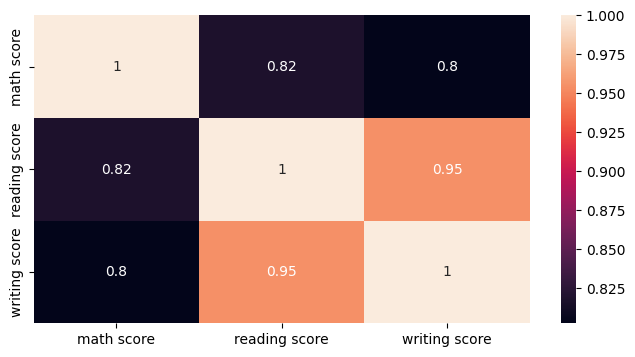

In [82]:
plt.figure(figsize=(8,4))
sns.heatmap(corr_mat, annot=True)
plt.show()

In [83]:
import numpy as np

# Use the existing corr_mat (correlation matrix)
abs_corr = corr_mat.abs()

# Set diagonal to NaN to ignore self-correlations
np.fill_diagonal(abs_corr.values, np.nan)

# Find the minimum absolute correlation value
min_corr_value = abs_corr.min().min()

# Find the column pair with the minimum correlation
min_corr_pair = abs_corr.stack().idxmin()

print(f"Least correlated pair: {min_corr_pair}")
print(f"Absolute correlation value: {min_corr_value}")

Least correlated pair: ('math score', 'writing score')
Absolute correlation value: 0.8026420459498075


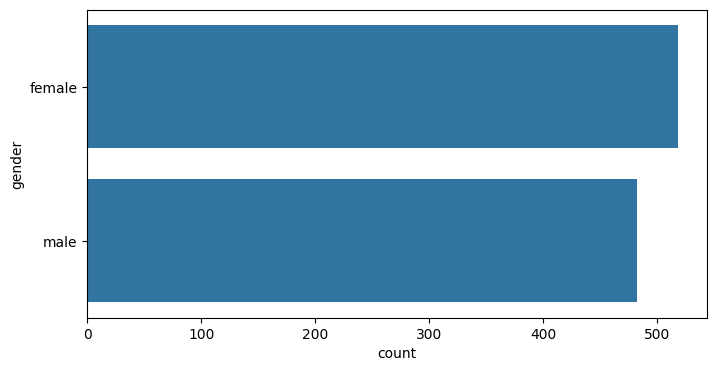

In [84]:
plt.figure(figsize=(8,4))
sns.countplot(data=df['gender'])
plt.show()

In [85]:
l = ['a', 'b', 'c', 'd']
print(dict(enumerate(l)))

{0: 'a', 1: 'b', 2: 'c', 3: 'd'}


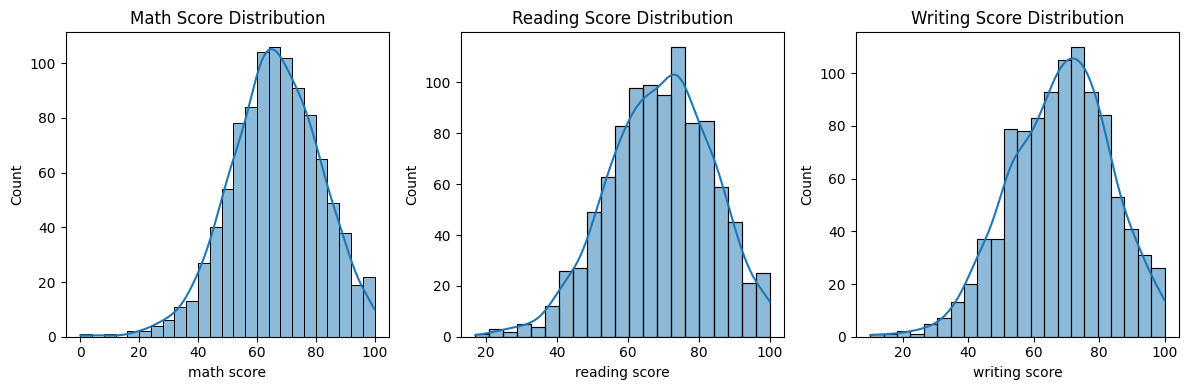

In [86]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, ax=ax[i], kde=True)
    ax[i].set_title(f'{col.title()} Distribution')

plt.tight_layout()
plt.show()

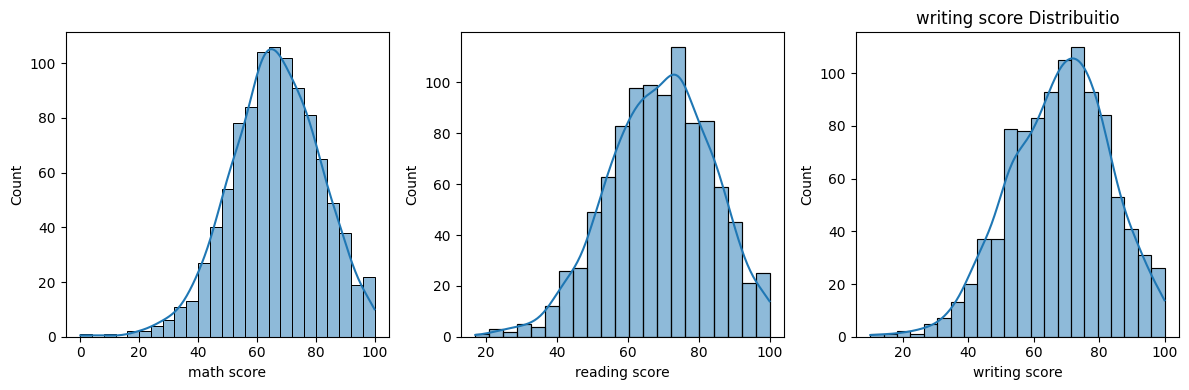

In [87]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col,ax=ax[i], kde=True)
    plt.title(f"{col} Distribuitio")

plt.tight_layout()
plt.show()

In [115]:
df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

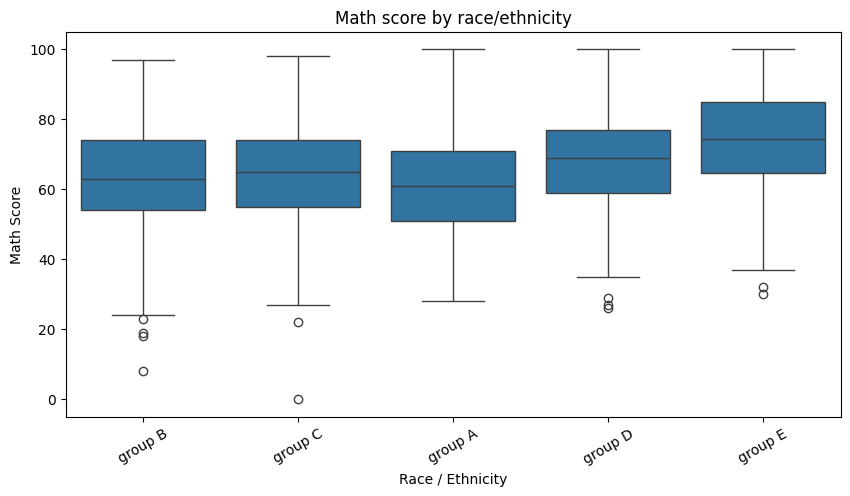

In [124]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='race/ethnicity', y='math score')
plt.title('Math score by race/ethnicity')
plt.xlabel('Race / Ethnicity')
plt.ylabel('Math Score')
plt.xticks(rotation=30)
plt.show()


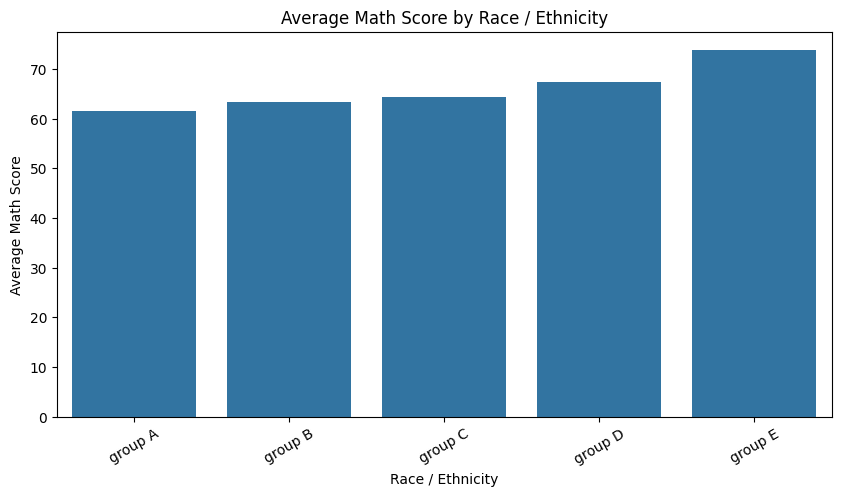

In [125]:
avg_scores = df.groupby('race/ethnicity')['math score'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_scores, x='race/ethnicity', y='math score')
plt.title('Average Math Score by Race / Ethnicity')
plt.xlabel('Race / Ethnicity')
plt.ylabel('Average Math Score')
plt.xticks(rotation=30)
plt.show()

<Axes: ylabel='math score'>

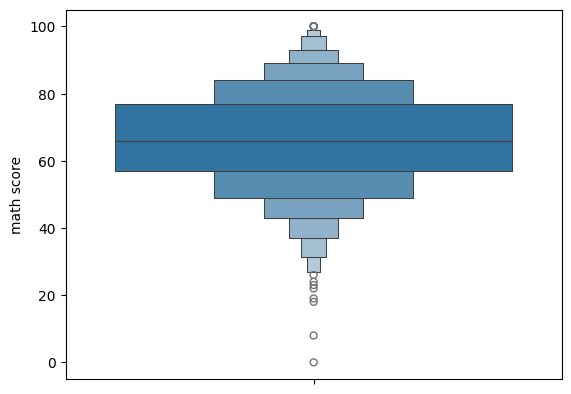

In [88]:
sns.boxenplot(y=df['math score'])

<Axes: ylabel='math score'>

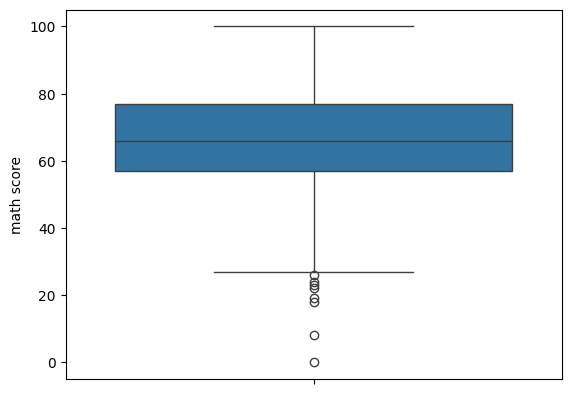

In [89]:
sns.boxplot(y=df['math score'])

In [5]:
iqr = df['math score'].quantile(0.75) - df['math score'].quantile(0.25)
lw_bnd = df['math score'].quantile(0.25) - 1.5 * iqr
up_bnd = df['math score'].quantile(0.75) + 1.5 * iqr

df[(df['math score']< lw_bnd) | (df['math score']> up_bnd)]



,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
145,female,group C,some college,free/reduced,none,22,39,33
338,female,group B,some high school,free/reduced,none,24,38,27
466,female,group D,associate's degree,free/reduced,none,26,31,38
787,female,group B,some college,standard,none,19,38,32
842,female,group B,high school,free/reduced,completed,23,44,36
980,female,group B,high school,free/reduced,none,8,24,23


# Preprocessing

In [6]:
cat_cols = df.select_dtypes(include=['object']).columns.to_list()

In [7]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

t_list = [
    ('ohe', OneHotEncoder(sparse_output=False), cat_cols),
    ('min_max', MinMaxScaler(), ['reading score', 'writing score'])
]

ct = ColumnTransformer(t_list, remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')



In [8]:
# Remove outliers before preprocessing
df_clean = df[~((df['math score'] < lw_bnd) | (df['math score'] > up_bnd))].copy()

print(f"Original dataset shape: {df.shape}")
print(f"After removing outliers: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

Original dataset shape: (1000, 8)
After removing outliers: (992, 8)
Rows removed: 8


In [9]:
# Use cleaned data and proceed
X = df_clean.drop(columns=['math score'])
y = df_clean['math score']

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (992, 7), y shape: (992,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
X_test.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
216,female,group E,associate's degree,free/reduced,completed,86,88
334,female,group C,bachelor's degree,standard,none,93,95
506,male,group A,high school,standard,none,70,66
312,male,group D,bachelor's degree,standard,completed,61,68
90,female,group C,bachelor's degree,standard,none,72,74


In [97]:
num_cols

['math score', 'reading score', 'writing score']

In [98]:
from sklearn.preprocessing import StandardScaler

# # Option 1: MinMaxScaler (scales to 0-1, good for neural networks)
# scaler_minmax = MinMaxScaler()
# y_train_scaled_mm = scaler_minmax.fit_transform(y_train.values.reshape(-1, 1)).flatten()
# y_test_scaled_mm = scaler_minmax.transform(y_test.values.reshape(-1, 1)).flatten()

# Option 2: StandardScaler (standardizes to mean=0, std=1, good for linear models)
# scaler_std = StandardScaler()
# y_train_scaled_std = scaler_std.fit_transform(y_train.values.reshape(-1, 1)).flatten()
# y_test_scaled_std = scaler_std.transform(y_test.values.reshape(-1, 1)).flatten()

# print("✅ Target scaling options created:")
# print(f"MinMaxScaler - Train range: [{y_train_scaled_mm.min():.3f}, {y_train_scaled_mm.max():.3f}]")
# print(f"StandardScaler - Train mean: {y_train_scaled_std.mean():.3f}, std: {y_train_scaled_std.std():.3f}")

# Choose based on your model:
# Use y_train, y_test for tree-based models (no scaling needed)
# Use y_train_scaled_std, y_test_scaled_std for Linear/Ridge/Lasso
# Use y_train_scaled_mm, y_test_scaled_mm for Neural Networks

In [16]:
scl_std = StandardScaler()
y_train_scl = scl_std.fit_transform(y_train.values.reshape(-1,1)).flatten()
y_test_scl = scl_std.transform(y_test.values.reshape(-1,1)).flatten()


In [12]:
X_train_enc = ct.fit_transform(X_train)
X_test_enc = ct.transform(X_test)

In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures

In [19]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'SGDRegressor': SGDRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'GradientBoostingRegressor': GradientBoostingRegressor(),
    # 'Poly Regression': PolynomialFeatures(degree=2)
}

In [20]:
from sklearn.metrics import r2_score, root_mean_squared_error

In [104]:
results = []
for name, model in models.items(): 
    print(f"Training Model: {name}")

    model.fit(X_train_enc, y_train_scl)
    y_pred = model.predict(X_test_enc)
    r2scr = r2_score(y_test_scl, y_pred)
    rsme = root_mean_squared_error(y_test_scl, y_pred)

    results.append({
        "Model": name,
        "r2_score": r2scr,
        "RSME": rsme
    })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RSME")
print(results_df)

Training Model: Linear Regression
Training Model: Ridge
Training Model: Lasso
Training Model: SGDRegressor
Training Model: Decision Tree


Training Model: Random Forest
Training Model: GradientBoostingRegressor
                       Model  r2_score      RSME
0          Linear Regression  0.886912  0.353332
1                      Ridge  0.883744  0.358246
6  GradientBoostingRegressor  0.872513  0.375151
5              Random Forest  0.863681  0.387929
3               SGDRegressor  0.836160  0.425289
4              Decision Tree  0.754505  0.520589
2                      Lasso -0.004294  1.052942


In [105]:
results_df

,Model,r2_score,RSME
0,Linear Regression,0.886912,0.353332
1,Ridge,0.883744,0.358246
6,GradientBoostingRegressor,0.872513,0.375151
5,Random Forest,0.863681,0.387929
3,SGDRegressor,0.836160,0.425289
4,Decision Tree,0.754505,0.520589
2,Lasso,-0.004294,1.052942


In [106]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

model_grids = [
    (
        'Linear Regression',
        LinearRegression(),
        {
            'model__fit_intercept': [True, False],
        }
    ),
    (
        'Ridge',
        Ridge(),
        {
            'model__alpha': [0.1, 1.0, 10.0],
            'model__solver': ['auto'],
        }
    ),
    (
        'Gradient Boosting',
        GradientBoostingRegressor(random_state=42),
        {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5],
        }
    )
]

# results_tuning = []
# for name, estimator, param_grid in model_grids:
#     print(f"Tuning: {name}")
#     pipe = Pipeline([
#         ('preproc', ct),
#         ('model', estimator)
#     ])

#     grid = GridSearchCV(
#         pipe,
#         param_grid,
#         cv=5,
#         scoring='neg_root_mean_squared_error',
#         n_jobs=-1,
#         verbose=1
#     )

#     grid.fit(X_train, y_train_scl)

#     best_pipe = grid.best_estimator_
#     y_pred = best_pipe.predict(X_test)

#     test_rmse = root_mean_squared_error(y_test_scl, y_pred)
#     test_r2 = r2_score(y_test_scl, y_pred)

#     results_tuning.append({
#         'Model': name,
#         'Best Params': grid.best_params_,
#         'CV RMSE': -grid.best_score_,
#         'Test RMSE': test_rmse,
#         'Test R2': test_r2
#     })

# results_tuning_df = pd.DataFrame(results_tuning).sort_values(by='Test RMSE')
# print(results_tuning_df)


In [21]:
from sklearn.pipeline import Pipeline

In [108]:
results_tuning = []

for name, model, param in model_grids:

    pipe = Pipeline([
        ('prepro', ct),
        ('model', model)
    ])

    grid = GridSearchCV(pipe,
                    param,
                    cv=5,
                    scoring='neg_root_mean_squared_error',
                    n_jobs=1,
                    verbose=True)
    
    grid.fit(X_train, y_train_scl)

    best_pipe = grid.best_estimator_

    y_pred = best_pipe.predict(X_test)

    r2scr = r2_score(y_test_scl, y_pred)

    rsme = root_mean_squared_error(y_test_scl, y_pred)

    results_tuning.append({
        'model_name': name,
        "Best Param": grid.best_params_,
        "r2_score": r2scr,
        "rsme": rsme
    })


results_df = pd.DataFrame(results_tuning).sort_values(by='rsme', ascending=False)
results_df



Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,model_name,Best Param,r2_score,rsme
2,Gradient Boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.876753,0.368861
1,Ridge,"{'model__alpha': 0.1, 'model__solver': 'auto'}",0.886603,0.353813
0,Linear Regression,{'model__fit_intercept': True},0.886912,0.353332


In [109]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial Regression with different degrees
poly_results = []

for degree in [2, 3]:
    print(f"\n{'='*50}")
    print(f"Training Polynomial Regression (Degree {degree})")
    print(f"{'='*50}")
    
    poly_pipe = Pipeline([
        ('preproc', ct),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', Ridge())
    ])
    
    poly_grid = GridSearchCV(
        poly_pipe,
        param_grid={'model__alpha': [0.1, 1.0, 10.0]},
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    poly_grid.fit(X_train, y_train_scl)
    
    best_poly_pipe = poly_grid.best_estimator_
    y_pred_poly = best_poly_pipe.predict(X_test)
    
    r2_poly = r2_score(y_test_scl, y_pred_poly)
    rmse_poly = root_mean_squared_error(y_test_scl, y_pred_poly)
    
    poly_results.append({
        'Model': f'Polynomial Regression (Degree {degree})',
        'Best Alpha': poly_grid.best_params_['model__alpha'],
        'Test RMSE': rmse_poly,
        'Test R2': r2_poly
    })
    
    print(f"Best Alpha: {poly_grid.best_params_['model__alpha']}")
    print(f"Test RMSE: {rmse_poly:.4f}")
    print(f"Test R2: {r2_poly:.4f}")

poly_df = pd.DataFrame(poly_results)
print("\n" + "="*50)
print("Polynomial Regression Results:")
print("="*50)
print(poly_df)


Training Polynomial Regression (Degree 2)
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Alpha: 10.0
Test RMSE: 0.3800
Test R2: 0.8692

Training Polynomial Regression (Degree 3)
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Alpha: 10.0
Test RMSE: 0.3781
Test R2: 0.8705

Polynomial Regression Results:
                              Model  Best Alpha  Test RMSE   Test R2
0  Polynomial Regression (Degree 2)        10.0   0.379953  0.869229
1  Polynomial Regression (Degree 3)        10.0   0.378148  0.870468


In [114]:
from sklearn.preprocessing import PolynomialFeatures

ply_results = []

for degree in [2,3]:

    pipe = Pipeline([
        ('preproc', ct),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', Ridge())
        
    ])

    poly_grid = GridSearchCV(
        pipe,
        param_grid={'model__alpha': [0.1, 1.0, 10.0]},
        cv=5,
        scoring= 'neg_root_mean_squared_error', 
        n_jobs=-1,
        verbose=1
    )

    poly_grid.fit(X_train, y_train_scl)

    best_pipe = poly_grid.best_estimator_

    y_pred = best_pipe.predict(X_test)

    r2scr = r2_score(y_test_scl, y_pred)
    rmse = root_mean_squared_error(y_test_scl, y_pred)

    ply_results.append({
        'Model': f'Polynomial Regression (Degree {degree})',
        'Best Alpha': poly_grid.best_params_['model__alpha'],
        'Test RMSE': rmse_poly,
        'Test R2': r2_poly
    })

poly_df = pd.DataFrame(ply_results)
print("\n" + "="*50)
print("Polynomial Regression Results:")
print("="*50)
print(poly_df)


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Polynomial Regression Results:
                              Model  Best Alpha  Test RMSE   Test R2
0  Polynomial Regression (Degree 2)        10.0   0.378148  0.870468
1  Polynomial Regression (Degree 3)        10.0   0.378148  0.870468


In [22]:
import joblib
import os

# Create a models directory if it doesn't exist
model_dir = 'saved_models'
os.makedirs(model_dir, exist_ok=True)

# Train final best model: Gradient Boosting (best performer from tuning)
final_pipe = Pipeline([
    ('preproc', ct),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

final_pipe.fit(X_train, y_train_scl)

# Save the model and preprocessing pipeline
joblib.dump(final_pipe, os.path.join(model_dir, 'student_score_model.pkl'))
joblib.dump(scl_std, os.path.join(model_dir, 'target_scaler.pkl'))

print("✅ Model saved successfully!")
print(f"   - Model: {os.path.join(model_dir, 'student_score_model.pkl')}")
print(f"   - Target Scaler: {os.path.join(model_dir, 'target_scaler.pkl')}")

# Verify with test predictions
y_pred_final = final_pipe.predict(X_test)
final_r2 = r2_score(y_test_scl, y_pred_final)
final_rmse = root_mean_squared_error(y_test_scl, y_pred_final)

print(f"\n🎯 Final Model Performance:")
print(f"   - R² Score: {final_r2:.4f}")
print(f"   - RMSE: {final_rmse:.4f}")


✅ Model saved successfully!
   - Model: saved_models\student_score_model.pkl
   - Target Scaler: saved_models\target_scaler.pkl

🎯 Final Model Performance:
   - R² Score: 0.8768
   - RMSE: 0.3689


In [24]:
# Load saved model and make predictions
loaded_model = joblib.load(os.path.join(model_dir, 'student_score_model.pkl'))
loaded_scaler = joblib.load(os.path.join(model_dir, 'target_scaler.pkl'))

# Test on a sample from test set
sample_idx = 5
sample_data = X_test.iloc[[sample_idx]]
actual_score_scaled = y_test_scl[sample_idx]
actual_score = y_test.iloc[sample_idx]

# Make prediction
pred_scaled = loaded_model.predict(sample_data)[0]
pred_actual = loaded_scaler.inverse_transform([[pred_scaled]])[0][0]

print("🧪 Test Prediction:")
print(f"   Actual Score: {actual_score:.1f}")
print(f"   Predicted Score: {pred_actual:.1f}")
print(f"   Error: {abs(actual_score - pred_actual):.1f} points")

🧪 Test Prediction:
   Actual Score: 75.0
   Predicted Score: 70.2
   Error: 4.8 points
